Demonstration of multi objective synthetic function

The synthetic problem to soleve is:
$$
\min_{x} \; \bigl(f_1(x), f_2(x)\bigr),
$$

We define endopoints $a = (0.20, 0.20), b = (0.72, 0.72)$ as the best point for each function, $f_1$ and $f_2$. Based on those endopoints, we designed Pareto set as

$$
x(t) = (1-t)a + tb, \qquad t\in [0,1]
$$

- \(t=0\) では目的1が最良である．
- \(t=1\) では目的2が最良である．
- \(0<t<1\) では目的1と目的2の trade-off が発生する．

この関数では，入力 $x$ を，線分方向の座標 $z(x)$ と，線分からの距離 $r(x)$ に分解している．

$$
z(x)
=
\frac{(x-a)^\top(b-a)}
{\|b-a\|^2}, \qquad
r^2(x)
=
\|x-\pi(x)\|^2, \qquad
\pi(x)
=
a + z(x)(b-a)
$$

このとき目的関数は
$$
f_1(x)
=
-
\exp\left(
-\frac{z(x)^2}{2\sigma_z^2}
\right)
\exp\left(
-\frac{r^2(x)}{2\sigma_\perp^2}
\right), \qquad

f_2(x)
=
-
\exp\left(
-\frac{(1-z(x))^2}{2\sigma_z^2}
\right)
\exp\left(
-\frac{r^2(x)}{2\sigma_\perp^2}
\right).
$$

例えば線分上であれば、$r^2(x)=0$なので
$
\exp\left(
-\frac{r^2(x)}{2\sigma_\perp^2}
\right)=1
$,
例えば線分上から外れれば、$r^2(x)>0$なので
$
\exp\left(
-\frac{r^2(x)}{2\sigma_\perp^2}
\right)=1
$
になる。

In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("./graph_preset.mplstyle")

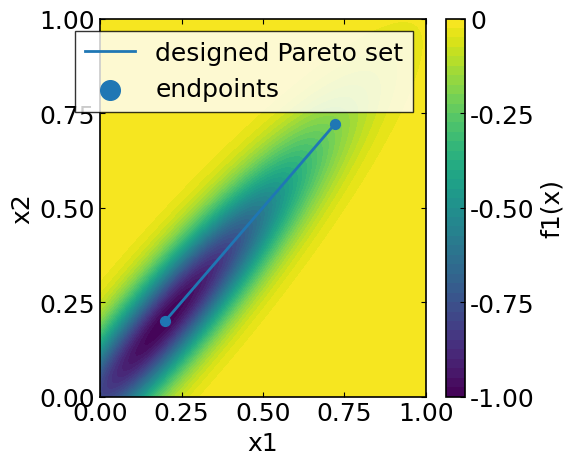

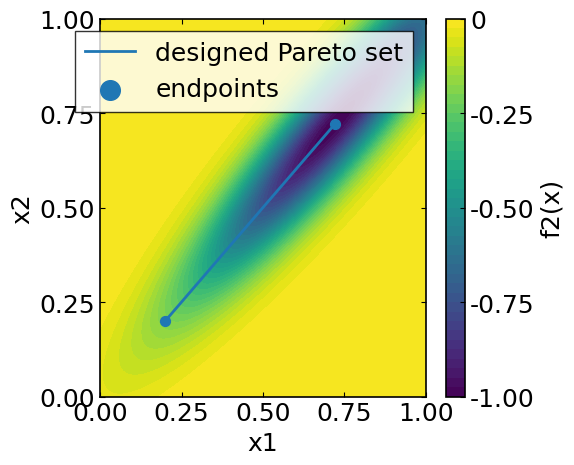

C:\Users\USER\AppData\Local\Temp\ipykernel_24268\612501668.py:182: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


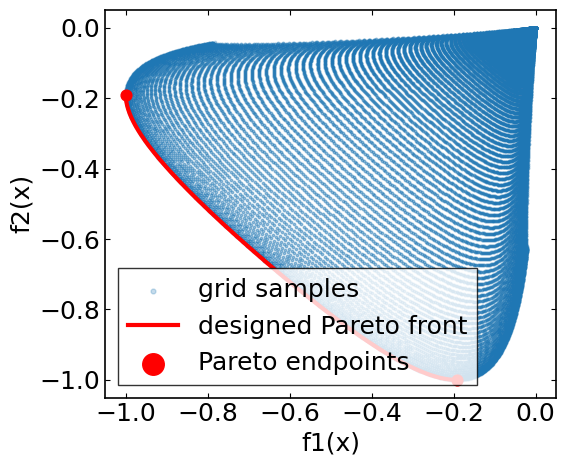

In [14]:
def multiobjective_line_pareto(x):
    """
    Two-objective noiseless synthetic function for minimization.

    Properties:
    - x in [0, 1]^2
    - Pareto set is approximately the line segment from a to b
    - Objectives are scaled to roughly [-1, 0]
    - Local correlation is induced by a shared corridor factor
    - Robustness is not encoded here; it is handled by robust_LCB
    """
    x = np.asarray(x, dtype=float)

    a = np.array([0.20, 0.20])
    b = np.array([0.72, 0.72])
    v = b - a
    vv = np.dot(v, v)

    sigma_z = 0.55
    sigma_perp = 0.08

    # normalized coordinate along the Pareto line
    z = np.sum((x - a) * v, axis=-1) / vv

    # projection onto the infinite line through a and b
    x_proj = a + z[..., None] * v

    # squared perpendicular distance from the line
    r2 = np.sum((x - x_proj) ** 2, axis=-1)

    # shared local-correlation corridor
    corridor = np.exp(-r2 / (2.0 * sigma_perp ** 2))

    # expected-performance objectives to be maximized
    g1 = np.exp(-(z ** 2) / (2.0 * sigma_z ** 2)) * corridor
    g2 = np.exp(-((1.0 - z) ** 2) / (2.0 * sigma_z ** 2)) * corridor

    # minimization convention
    f1 = -g1
    f2 = -g2

    return np.stack([f1, f2], axis=-1)


# ============================================================
# 1. Evaluate function on a dense grid
# ============================================================

n = 300

x1 = np.linspace(0.0, 1.0, n)
x2 = np.linspace(0.0, 1.0, n)

X1, X2 = np.meshgrid(x1, x2)

X = np.stack(
    [X1.ravel(), X2.ravel()],
    axis=-1
)

Y = multiobjective_line_pareto(X)

F1 = Y[:, 0].reshape(n, n)
F2 = Y[:, 1].reshape(n, n)


# ============================================================
# 2. Designed Pareto set in input space
# ============================================================

a = np.array([0.20, 0.20])
b = np.array([0.72, 0.72])

t = np.linspace(0.0, 1.0, 200)

pareto_x = (1.0 - t)[:, None] * a + t[:, None] * b
pareto_y = multiobjective_line_pareto(pareto_x)


# ============================================================
# 3. Plot f1 over input space
# ============================================================
# この関数は(0.2, 0.2)付近が最良、(0.75, 0.75)付近にいくと悪い。またこの2点を結ぶ線から垂直に離れると悪くなる。
plt.figure(figsize=(6, 5))

cs = plt.contourf(X1, X2, F1, levels=40)

cbar = plt.colorbar(cs, label="f1(x)")
cbar.set_ticks([0, -0.25, -0.50, -0.75, -1.00])
cbar.set_ticklabels(["0", "-0.25", "-0.50", "-0.75", "-1.00"])

plt.plot(
    pareto_x[:, 0],
    pareto_x[:, 1],
    linewidth=2,
    label="designed Pareto set"
)

plt.scatter(
    [a[0], b[0]],
    [a[1], b[1]],
    s=50,
    label="endpoints"
)

plt.xticks([0, 0.25, 0.50, 0.75, 1.00])
plt.yticks([0, 0.25, 0.50, 0.75, 1.00])
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 4. Plot f1 over input space with 3D projection
# ============================================================
# f1(x) の谷の形状を 3D surface として確認する。
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    X1,
    X2,
    F1,
    cmap="viridis",
    linewidth=0,
    antialiased=True,
    alpha=0.90,
)

# Pareto set を f1 の曲面上に重ねて表示する。
ax.plot(
    pareto_x[:, 0],
    pareto_x[:, 1],
    pareto_y[:, 0],
    color="red",
    linewidth=3,
    label="designed Pareto set on f1",
)

ax.scatter(
    [a[0], b[0]],
    [a[1], b[1]],
    [pareto_y[0, 0], pareto_y[-1, 0]],
    color="red",
    s=60,
    label="endpoints",
)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f1(x)")
ax.set_xticks([0, 0.25, 0.50, 0.75, 1.00])
ax.set_yticks([0, 0.25, 0.50, 0.75, 1.00])
ax.set_zlim(-1.0, 0.0)
ax.view_init(elev=30, azim=-100)
fig.colorbar(surf, ax=ax, shrink=0.65, pad=0.10, label="f1(x)")
ax.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 5. Plot f2 over input space
# ============================================================
# この関数は(0.75, 0.75)付近が最良、(0.2, 0.2)付近にいくと悪い。またこの2点を結ぶ線から垂直に離れると悪くなる。
plt.figure(figsize=(6, 5))

cs = plt.contourf(X1, X2, F2, levels=40)
cbar = plt.colorbar(cs, label="f2(x)")
cbar.set_ticks([0, -0.25, -0.50, -0.75, -1.00])
cbar.set_ticklabels(["0", "-0.25", "-0.50", "-0.75", "-1.00"])

plt.plot(
    pareto_x[:, 0],
    pareto_x[:, 1],
    linewidth=2,
    label="designed Pareto set"
)

plt.scatter(
    [a[0], b[0]],
    [a[1], b[1]],
    s=50,
    label="endpoints"
)

plt.xticks([0, 0.25, 0.50, 0.75, 1.00])
plt.yticks([0, 0.25, 0.50, 0.75, 1.00])
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 6. Plot f2 over input space with 3D projection
# ============================================================
# 2D の等高線図だけではなく、f2(x) の谷の形状を 3D surface として確認する。
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    X1,
    X2,
    F2,
    cmap="viridis",
    linewidth=0,
    antialiased=True,
    alpha=0.90,
)

# Pareto set を f2 の曲面上に重ねて表示する。
ax.plot(
    pareto_x[:, 0],
    pareto_x[:, 1],
    pareto_y[:, 1],
    color="red",
    linewidth=3,
    label="designed Pareto set on f2",
)

ax.scatter(
    [a[0], b[0]],
    [a[1], b[1]],
    [pareto_y[0, 1], pareto_y[-1, 1]],
    color="red",
    s=60,
    label="endpoints",
)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f2(x)")
ax.set_xticks([0, 0.25, 0.50, 0.75, 1.00])
ax.set_yticks([0, 0.25, 0.50, 0.75, 1.00])
ax.set_zlim(-1.0, 0.0)
ax.view_init(elev=30, azim=-100)
fig.colorbar(surf, ax=ax, shrink=0.65, pad=0.10, label="f2(x)")
ax.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 7. Plot objective space
# ============================================================

plt.figure(figsize=(6, 5))

plt.scatter(
    Y[:, 0],
    Y[:, 1],
    s=3,
    alpha=0.25,
    label="grid samples"
)

plt.plot(
    pareto_y[:, 0],
    pareto_y[:, 1],
    color="red",
    linewidth=3,
    label="designed Pareto front"
)

plt.scatter(
    [pareto_y[0, 0], pareto_y[-1, 0]],
    [pareto_y[0, 1], pareto_y[-1, 1]],
    color="red",
    s=60,
    label="Pareto endpoints"
)

plt.xlabel("f1(x)")
plt.ylabel("f2(x)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 8. Plot f1 + f2 over input space
# ============================================================
# f1 と f2 を足し合わせた値を可視化し、2 つの目的関数を同時に小さくできる領域を確認する。
F_SUM = F1 + F2
pareto_sum = pareto_y[:, 0] + pareto_y[:, 1]

# ------------------------------------------------------------
# 8.1 2D projection of f1 + f2 over input space
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))

cs = plt.contourf(X1, X2, F_SUM, levels=40)
cbar = plt.colorbar(cs, label="f1(x) + f2(x)")

plt.plot(
    pareto_x[:, 0],
    pareto_x[:, 1],
    linewidth=2,
    label="designed Pareto set"
)

plt.scatter(
    [a[0], b[0]],
    [a[1], b[1]],
    s=50,
    label="endpoints"
)

plt.xticks([0, 0.25, 0.50, 0.75, 1.00])
plt.yticks([0, 0.25, 0.50, 0.75, 1.00])
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8.2 3D projection of f1 + f2 over input space
# ------------------------------------------------------------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    X1,
    X2,
    F_SUM,
    cmap="viridis",
    linewidth=0,
    antialiased=True,
    alpha=0.90,
)

# Pareto set を f1 + f2 の曲面上に重ねて表示する。
ax.plot(
    pareto_x[:, 0],
    pareto_x[:, 1],
    pareto_sum,
    color="red",
    linewidth=3,
    label="designed Pareto set on f1 + f2",
)

ax.scatter(
    [a[0], b[0]],
    [a[1], b[1]],
    [pareto_sum[0], pareto_sum[-1]],
    color="red",
    s=60,
    label="endpoints",
)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f1(x) + f2(x)")
ax.set_xticks([0, 0.25, 0.50, 0.75, 1.00])
ax.set_yticks([0, 0.25, 0.50, 0.75, 1.00])
ax.set_zlim(F_SUM.min(), 0.0)
ax.view_init(elev=30, azim=-100)
fig.colorbar(surf, ax=ax, shrink=0.65, pad=0.10, label="f1(x) + f2(x)")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 9. Plot weighted sums of f1 and f2 over input space
# ============================================================
# f1 と f2 の重みを変えた 2 ケースを比較し、各ケースの最小点を定量的に表示する。
weighted_sum_cases = [
    (0.8, 0.2),
    (0.2, 0.8),
]

for w1, w2 in weighted_sum_cases:
    F_SUM = w1 * F1 + w2 * F2
    pareto_sum = w1 * pareto_y[:, 0] + w2 * pareto_y[:, 1]

    best_idx = np.argmin(F_SUM)
    x_best = X[best_idx]
    y_best = Y[best_idx]
    f_sum_best = F_SUM.ravel()[best_idx]

    print(f"F_SUM = {w1:.1f}*F1 + {w2:.1f}*F2")
    print(f"best_idx = {best_idx}")
    print(f"x_best = {x_best}")
    print(f"y_best = {y_best}")
    print(f"F_SUM(best) = {f_sum_best}")
    print()

    # ------------------------------------------------------------
    # 9.1 2D projection of weighted f1 + f2 over input space
    # ------------------------------------------------------------
    plt.figure(figsize=(6, 5))

    cs = plt.contourf(X1, X2, F_SUM, levels=40)
    cbar = plt.colorbar(cs, label=f"{w1:.1f} f1(x) + {w2:.1f} f2(x)")

    plt.plot(
        pareto_x[:, 0],
        pareto_x[:, 1],
        linewidth=2,
        label="designed Pareto set"
    )

    plt.scatter(
        [a[0], b[0]],
        [a[1], b[1]],
        s=50,
        label="endpoints"
    )

    plt.scatter(
        [x_best[0]],
        [x_best[1]],
        color="black",
        marker="*",
        s=120,
        label="best weighted-sum point"
    )

    plt.xticks([0, 0.25, 0.50, 0.75, 1.00])
    plt.yticks([0, 0.25, 0.50, 0.75, 1.00])
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"F_SUM = {w1:.1f} f1 + {w2:.1f} f2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # 9.2 3D projection of weighted f1 + f2 over input space
    # ------------------------------------------------------------
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(
        X1,
        X2,
        F_SUM,
        cmap="viridis",
        linewidth=0,
        antialiased=True,
        alpha=0.90,
    )

    ax.plot(
        pareto_x[:, 0],
        pareto_x[:, 1],
        pareto_sum,
        color="red",
        linewidth=3,
        label="designed Pareto set on weighted sum",
    )

    ax.scatter(
        [a[0], b[0]],
        [a[1], b[1]],
        [pareto_sum[0], pareto_sum[-1]],
        color="red",
        s=60,
        label="endpoints",
    )

    ax.scatter(
        [x_best[0]],
        [x_best[1]],
        [f_sum_best],
        color="black",
        marker="*",
        s=120,
        label="best weighted-sum point",
    )

    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_zlabel(f"{w1:.1f} f1(x) + {w2:.1f} f2(x)")
    ax.set_xticks([0, 0.25, 0.50, 0.75, 1.00])
    ax.set_yticks([0, 0.25, 0.50, 0.75, 1.00])
    ax.set_zlim(F_SUM.min(), 0.0)
    ax.view_init(elev=30, azim=-100)
    fig.colorbar(surf, ax=ax, shrink=0.65, pad=0.10, label=f"{w1:.1f} f1(x) + {w2:.1f} f2(x)")
    ax.legend()
    plt.tight_layout()
    plt.show()


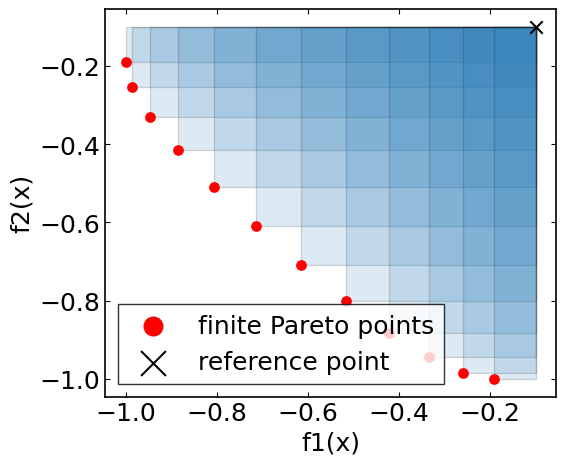

In [5]:
# ============================================================
# Plot objective space with red Pareto front and staircase HV
# ============================================================

# Use a finite subset of Pareto points to show staircase structure
m = 12
idx = np.linspace(0, len(pareto_y) - 1, m).astype(int)
P = pareto_y[idx]

# Reference point for minimization
ref = np.array([-0.1, -0.1])
# ref = np.array([0.0, 0.0])      # wider reference point
# ref = np.array([-0.5, -0.5])    # narrower, clips the dominated region

# Keep only points that dominate the reference point
# For minimization, p dominates ref if p[0] <= ref[0] and p[1] <= ref[1]
P = P[(P[:, 0] <= ref[0]) & (P[:, 1] <= ref[1])]

# Sort from left to right in f1
P = P[np.argsort(P[:, 0])]

plt.figure(figsize=(6, 5))

# All objective samples
#plt.scatter(
#    Y[:, 0],
#    Y[:, 1],
#    s=3,
#    alpha=0.15,
#    label="grid samples"
#)

# True designed Pareto front
#plt.plot(
#    pareto_y[:, 0],
#    pareto_y[:, 1],
#    color="red",
#    linewidth=3,
#    label="true designed Pareto front"
#)

# Finite Pareto approximation points
plt.scatter(
    P[:, 0],
    P[:, 1],
    color="red",
    s=45,
    zorder=3,
    label="finite Pareto points"
)

# Draw dominated rectangles
for p in P:
    width = ref[0] - p[0]
    height = ref[1] - p[1]

    rect = plt.Rectangle(
        (p[0], p[1]),
        width,
        height,
        fill=True,
        alpha=0.15,
        edgecolor="black"
    )
    plt.gca().add_patch(rect)

# Draw reference point
plt.scatter(
    [ref[0]],
    [ref[1]],
    color="black",
    marker="x",
    s=80,
    label="reference point"
)

plt.xlabel("f1(x)")
plt.ylabel("f2(x)")
plt.legend()
plt.tight_layout()
plt.show()